# Lab 5 - ML Models (Clustering) 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

iris = load_iris()
X = iris.data   
y = iris.target
print(X.shape)
X


(150, 4)


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

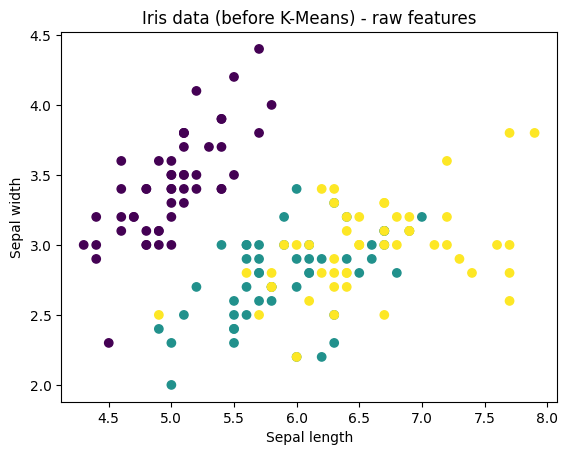

In [2]:
plt.figure()

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Iris data (before K-Means) - raw features")

plt.show()

In [3]:
scaler = StandardScaler()  # important for KMeans
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    init="k-means++", # random
    n_init=10, # Number of times the k-means algorithm is run with different centroid seeds.
    random_state=42, # random number generation for centroid initialization
    max_iter=10, # Maximum number of iterations of the k-means algorithm for a single run
    tol=1e-4, # difference in the cluster centers of two consecutive iterations to declare convergence.
)

labels = kmeans.fit_predict(X_scaled)
print(labels)
centroids = kmeans.cluster_centers_
print(centroids)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


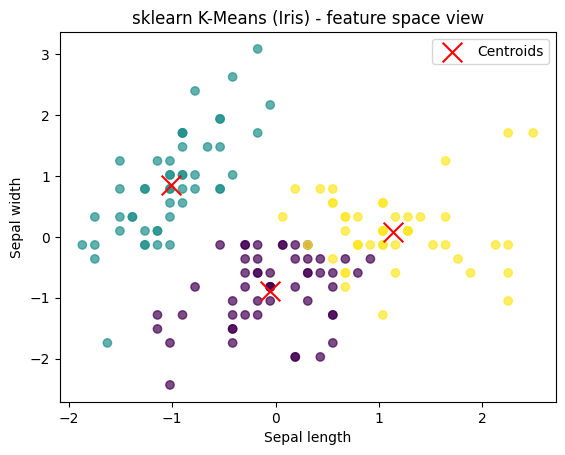

In [4]:
plt.figure()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', alpha=0.7)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    color='red',
    marker='x',
    s=200,
    label='Centroids'
)

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("sklearn K-Means (Iris) - feature space view")
plt.legend()

plt.show()

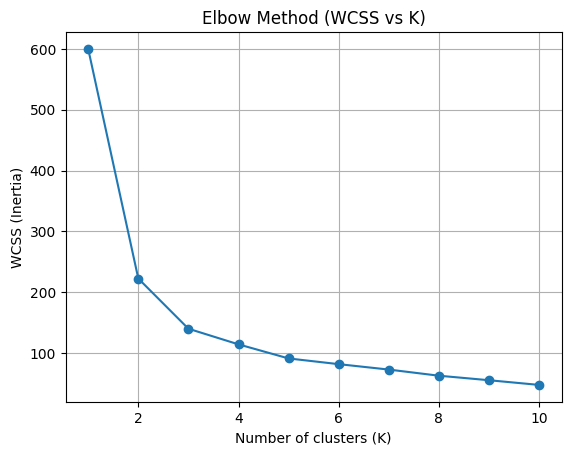

In [5]:

# Elbow Method (WCSS / inertia)

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # WCSS


plt.figure()
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method (WCSS vs K)")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()



In [6]:
best_k = 3  # Iris typically has 3 clusters

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(X_scaled)

print("Cluster labels:", labels)

Cluster labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [7]:
label_names = {0: "group1", 1: "group2", 2: "group3"}
named_labels = [label_names[l] for l in labels]
named_labels

['group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group2',
 'group3',
 'group3',
 'group3',
 'group1',
 'group1',
 'group1',
 'group3',
 'group1',
 'group1',
 'group1',
 'group1',
 'group1',
 'group1',
 'group1',
 'group1',
 'group3',
 'group1',
 'group1',
 'group1',
 'group1',
 'group3',
 'group1',
 'group1',
 'group1',
 'group1',
 'group3',
 'group3',
 'group3',
 'group1',
 'group1',
 'group1',
 'group1',
 'group1',
 'group1',
 'group1',
 'group3',
 'group3',
 'group1',
 'group1',
 'group1',
 'group1',

In [8]:
# Compare
df = pd.DataFrame({
    "cluster": named_labels,
    "true_label": y
})

print(df.sample(20))

    cluster  true_label
124  group3           2
105  group3           2
84   group1           1
44   group2           0
20   group2           0
140  group3           2
107  group3           2
61   group1           1
26   group2           0
101  group1           2
131  group3           2
45   group2           0
11   group2           0
10   group2           0
145  group3           2
82   group1           1
144  group3           2
6    group2           0
65   group3           1
53   group1           1
